=== Data Loading & Integration ===
Found 1097 electricity JSON files.
Electricity DataFrame Shape: (301642, 7)
Electricity DataFrame Columns: ['period', 'subba', 'subba-name', 'parent', 'parent-name', 'value', 'value-units']

Found 63 weather CSV files.
Weather DataFrame Shape: (127584, 2)
Weather DataFrame Columns: ['date', 'temperature_2m']

=== Data Preprocessing ===
Electricity Data: Removing 12056 duplicate rows.
Weather Data: Removing 97608 duplicate rows.
Merged DataFrame Shape: (26321, 4)
Merged DataFrame Columns: ['datetime', 'electricity_demand_mwh', 'datetime_string', 'temperature_2m_c']

Missing Data Percentage per Column:
 datetime                  0.0
electricity_demand_mwh    0.0
datetime_string           0.0
temperature_2m_c          0.0
dtype: float64

Outliers in Electricity Demand (IQR): 818
Outliers in Temperature (|Z|>3): 10

Data Preprocessing Complete.

=== Exploratory Data Analysis (EDA) ===

Detailed Statistical Summary:
                           count        

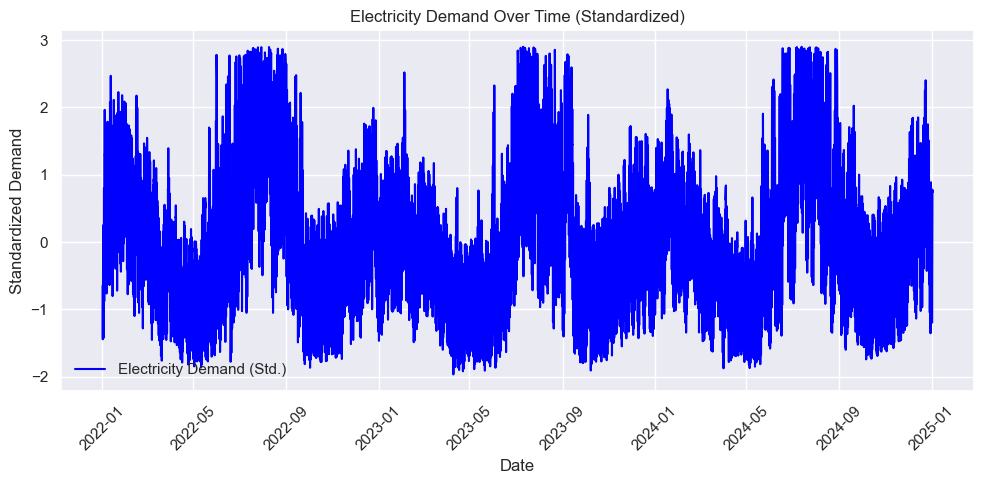

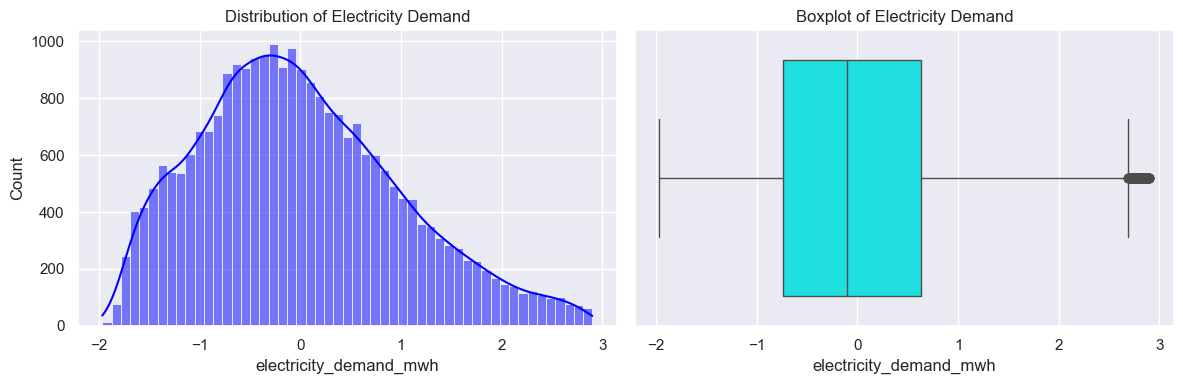

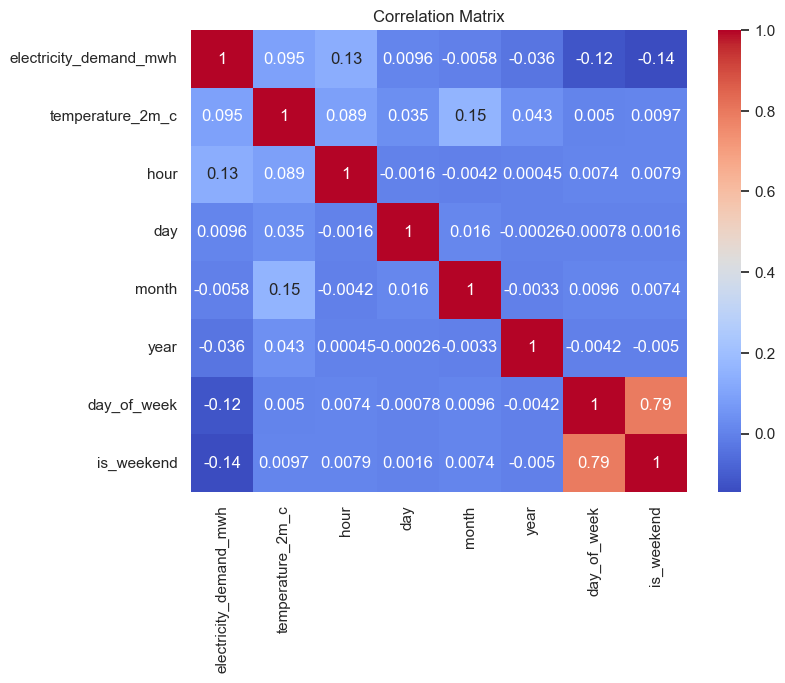

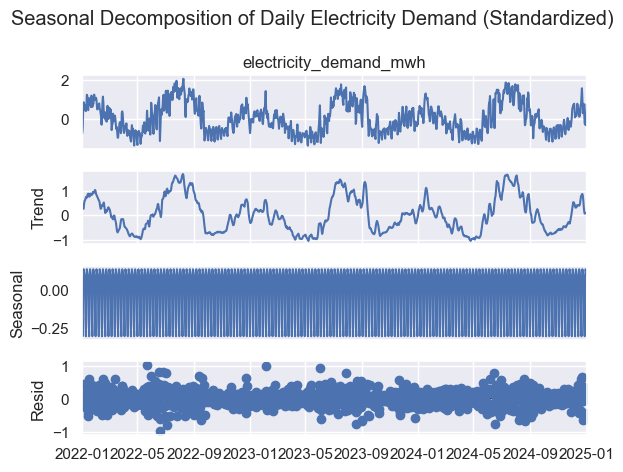


Augmented Dickey-Fuller Test Results:
ADF Statistic: -3.432584193904214
p-value: 0.00989698033763551
Critical Values: {'1%': np.float64(-3.436441978605957), '5%': np.float64(-2.864229841568573), '10%': np.float64(-2.5682021659802934)}
=> The time series is likely stationary (p < 0.05).

=== Regression Modeling ===

Model Performance Metrics:
MSE:  1.1060
RMSE: 1.0516
R²:   -0.0064


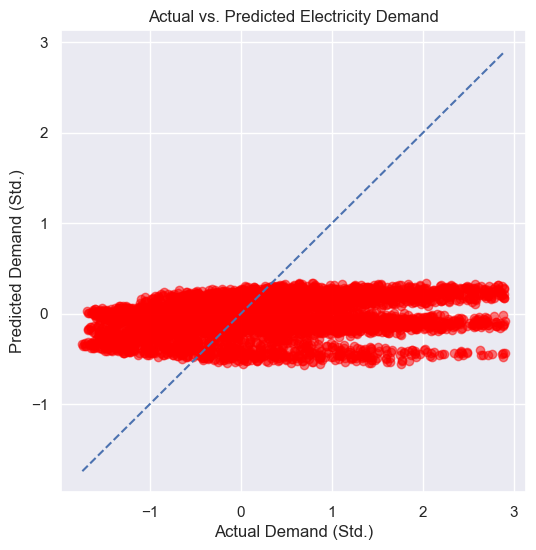

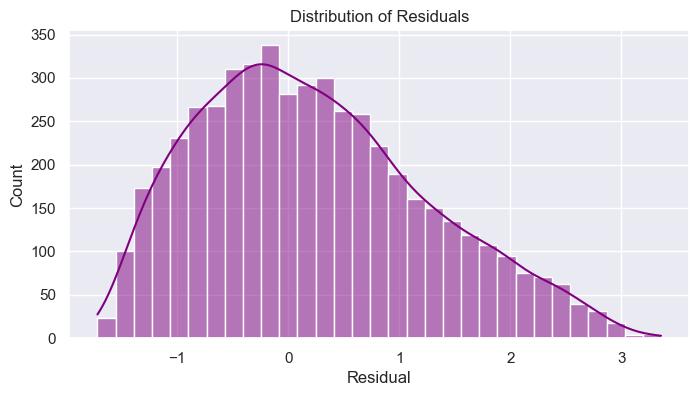

Residual Mean: 0.22561824209306888
If the residual mean is close to 0, the model doesn't show large bias.

Final cleaned & processed data saved to: final_cleaned_merged_data.csv

Program completely executed!


In [10]:
#Setup
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For time series decomposition and stationarity tests
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# For scaling and modeling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# plots 
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_theme()

# directory structure 
BASE_PATH = r"C:\Users\walee\OneDrive\Desktop\22I2647_BSE8B_AssNo.2\Data\raw"
ELECTRICITY_PATH = os.path.join(BASE_PATH, "electricity_raw_data")
WEATHER_PATH = os.path.join(BASE_PATH, "weather_raw_data")



# Loading data and integrating it 
"""
- Scan data folders (electricity & weather) using os/glob.
- Load JSON (electricity) & CSV (weather).
- Validate file formats, handle encoding.
- Merge them into a single DataFrame.
- Log the number of records & features, note immediate anomalies.
"""

print("=== Data Loading & Integration ===")

# Load Electricity JSON Files
electricity_json_files = glob.glob(os.path.join(ELECTRICITY_PATH, "*.json"))
print(f"Found {len(electricity_json_files)} electricity JSON files.")

electricity_dfs = []
for file in electricity_json_files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        df_temp = pd.DataFrame(data["response"]["data"])
        electricity_dfs.append(df_temp)

df_elec = pd.concat(electricity_dfs, ignore_index=True)

print(f"Electricity DataFrame Shape: {df_elec.shape}")
print("Electricity DataFrame Columns:", df_elec.columns.tolist())
if df_elec.empty:
    print("WARNING: Electricity DataFrame is empty!")

# Load Weather CSV Files
weather_csv_files = glob.glob(os.path.join(WEATHER_PATH, "*.csv"))
print(f"\nFound {len(weather_csv_files)} weather CSV files.")

weather_dfs = []
for file in weather_csv_files:
    df_temp = pd.read_csv(file)
    weather_dfs.append(df_temp)

df_weather = pd.concat(weather_dfs, ignore_index=True)

print(f"Weather DataFrame Shape: {df_weather.shape}")
print("Weather DataFrame Columns:", df_weather.columns.tolist())
if df_weather.empty:
    print("WARNING: Weather DataFrame is empty!")


# Data Preprocessing
"""
1) Data Cleaning & Consistency:
   a) Missing Data
   b) Data Type Conversions
   c) Duplicates & Outliers
2) Feature Engineering
3) Documentation
"""

print("\n=== Data Preprocessing ===")

# Electricity Data Cleaning
df_elec.rename(columns={
    "period": "datetime_string",
    "value": "electricity_demand_mwh"
}, inplace=True)

# Convert demand to numeric
df_elec["electricity_demand_mwh"] = pd.to_numeric(df_elec["electricity_demand_mwh"], errors="coerce")

# Convert datetime string to datetime
# YYYY-MM-DDTHH
df_elec["datetime"] = pd.to_datetime(df_elec["datetime_string"], format="%Y-%m-%dT%H", errors="coerce")

# Convert subba, parent to categorical if they exist
if "subba" in df_elec.columns:
    df_elec["subba"] = df_elec["subba"].astype("category")
if "parent" in df_elec.columns:
    df_elec["parent"] = df_elec["parent"].astype("category")

# Remove duplicates
num_dups_elec = df_elec.duplicated().sum()
if num_dups_elec > 0:
    print(f"Electricity Data: Removing {num_dups_elec} duplicate rows.")
    df_elec.drop_duplicates(inplace=True)

# Aggregate subregions to get total hourly demand
df_elec = df_elec.groupby("datetime", as_index=False)["electricity_demand_mwh"].sum()


# Weather Data Cleaning
df_weather.rename(columns={
    "date": "datetime_string",
    "temperature_2m": "temperature_2m_c"
}, inplace=True)

# Convert datetime
df_weather["datetime"] = pd.to_datetime(df_weather["datetime_string"], errors="coerce").dt.tz_localize(None)

# Convert temperature to numeric
df_weather["temperature_2m_c"] = pd.to_numeric(df_weather["temperature_2m_c"], errors="coerce")

# Remove duplicates
num_dups_weather = df_weather.duplicated().sum()
if num_dups_weather > 0:
    print(f"Weather Data: Removing {num_dups_weather} duplicate rows.")
    df_weather.drop_duplicates(inplace=True)

# Merge Electricity & Weather
df_merged = pd.merge(df_elec, df_weather, on="datetime", how="inner")

print(f"Merged DataFrame Shape: {df_merged.shape}")
print("Merged DataFrame Columns:", df_merged.columns.tolist())

# Missing Data Analysis
missing_percent = df_merged.isnull().mean() * 100
print("\nMissing Data Percentage per Column:\n", missing_percent)

# if missing is low, treat as MCAR and drop
# If it's large or has patterns, consider MAR or MNAR
# I'll assume small missing => drop
df_merged.dropna(inplace=True)

# Outlier Detection & Removal
# IQR-based on electricity demand
Q1 = df_merged["electricity_demand_mwh"].quantile(0.25)
Q3 = df_merged["electricity_demand_mwh"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers_elec = df_merged[
    (df_merged["electricity_demand_mwh"] < lower_bound) |
    (df_merged["electricity_demand_mwh"] > upper_bound)
]
print(f"\nOutliers in Electricity Demand (IQR): {len(df_outliers_elec)}")

# Remove them for demonstration
df_merged = df_merged[
    (df_merged["electricity_demand_mwh"] >= lower_bound) &
    (df_merged["electricity_demand_mwh"] <= upper_bound)
]

# Z-score method for temperature
df_merged["temp_zscore"] = (
    df_merged["temperature_2m_c"] - df_merged["temperature_2m_c"].mean()
) / df_merged["temperature_2m_c"].std()

df_outliers_temp = df_merged[np.abs(df_merged["temp_zscore"]) > 3]
print(f"Outliers in Temperature (|Z|>3): {len(df_outliers_temp)}")

# Remove them
df_merged = df_merged[np.abs(df_merged["temp_zscore"]) <= 3]
df_merged.drop(columns=["temp_zscore"], inplace=True)

# Feature Engineering
df_merged["hour"] = df_merged["datetime"].dt.hour
df_merged["day"] = df_merged["datetime"].dt.day
df_merged["month"] = df_merged["datetime"].dt.month
df_merged["year"] = df_merged["datetime"].dt.year
df_merged["day_of_week"] = df_merged["datetime"].dt.dayofweek
df_merged["is_weekend"] = df_merged["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# standardize numeric features
scaler = StandardScaler()
df_merged[["electricity_demand_mwh", "temperature_2m_c"]] = scaler.fit_transform(
    df_merged[["electricity_demand_mwh", "temperature_2m_c"]]
)

print("\nData Preprocessing Complete.")


# Exploratory Data Analysis (EDA)
"""
- Statistical summary: mean, median, std, skewness, kurtosis
- Time series analysis: plot demand, highlight trends
- Univariate analysis: histograms, boxplots, density
- Correlation analysis: correlation matrix, discuss multicollinearity
- Advanced time series: decomposition, ADF test
"""

print("\n=== Exploratory Data Analysis (EDA) ===")

# Statistical Summary
desc_stats = df_merged.describe().T
desc_stats["skew"] = df_merged.skew(numeric_only=True)
desc_stats["kurtosis"] = df_merged.kurtosis(numeric_only=True)
print("\nDetailed Statistical Summary:\n", desc_stats)

# Time Series Plot of Electricity Demand
plt.figure(figsize=(10, 5))
plt.plot(df_merged["datetime"], df_merged["electricity_demand_mwh"], label="Electricity Demand (Std.)", color="blue")
plt.title("Electricity Demand Over Time (Standardized)")
plt.xlabel("Date")
plt.ylabel("Standardized Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

# Univariate Analysis (Histograms & Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_merged["electricity_demand_mwh"], ax=axes[0], kde=True, color="blue")
axes[0].set_title("Distribution of Electricity Demand")

sns.boxplot(x=df_merged["electricity_demand_mwh"], ax=axes[1], color="cyan")
axes[1].set_title("Boxplot of Electricity Demand")

plt.tight_layout()
plt.show()

# Correlation Matrix
corr_matrix = df_merged.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Check for multicollinearity (if any correlation > 0.8)
high_corr = (corr_matrix > 0.8) & (corr_matrix != 1.0)
if high_corr.sum().sum() > 0:
    print("Potential multicollinearity found in the dataset. Consider dimension reduction or feature selection.")

# Advanced Time Series Techniques (Decomposition & Stationarity)
# set datetime as index.
df_ts = df_merged.set_index("datetime").sort_index()

# do a daily average to make decomposition simpler:
df_daily = df_ts.resample("D")["electricity_demand_mwh"].mean().dropna()

# Seasonal Decomposition
# model='additive' 
decomp_result = seasonal_decompose(df_daily, model='additive', period=7)  # period=7 for weekly seasonality
decomp_result.plot()
plt.suptitle("Seasonal Decomposition of Daily Electricity Demand (Standardized)")
plt.tight_layout()
plt.show()

# ADF Test for stationarity
adf_test = adfuller(df_daily.dropna(), autolag="AIC")
print("\nAugmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print("Critical Values:", adf_test[4])
if adf_test[1] < 0.05:
    print("=> The time series is likely stationary (p < 0.05).")
else:
    print("=> The time series is likely non-stationary (p >= 0.05).")



# Regression Modeling
"""
- Build & evaluate regression model for electricity demand.
- Use time-based features + temperature as predictors.
- Evaluate with MSE, RMSE, R².
- Plot actual vs. predicted, do residual analysis.
"""

print("\n=== Regression Modeling ===")

# Feature Selection
# predict 'electricity_demand_mwh' using time-based features and temperature
# (both standardized).
df_merged = df_merged.sort_values("datetime")  # ensure chronological order if needed
features = ["temperature_2m_c", "hour", "day_of_week", "is_weekend"]
X = df_merged[features]
y = df_merged["electricity_demand_mwh"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)  
# shuffle=False to respect time ordering in a naive sense

# Build & Fit Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance Metrics:")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="red")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Actual Demand (Std.)")
plt.ylabel("Predicted Demand (Std.)")
plt.title("Actual vs. Predicted Electricity Demand")
plt.show()

# Residual Analysis
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

print("Residual Mean:", np.mean(residuals))
print("If the residual mean is close to 0, the model doesn't show large bias.\n")


# Save Final Data
output_csv_path = "final_cleaned_merged_data.csv"
df_merged.to_csv(output_csv_path, index=False)
print(f"Final cleaned & processed data saved to: {output_csv_path}")

print("\nProgram completely executed!")
